In [33]:
from itertools import product
import pickle
from tqdm import tqdm, trange

import numpy as np
from numpy.linalg import eigh
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Ellipse
from corner import corner as corner_plot

from scipy import special, stats
from scipy.spatial import Delaunay, ConvexHull
from scipy.stats import gaussian_kde, chi2
from scipy.interpolate import RegularGridInterpolator

import os

from local_utils import delaunaytor
from popsummary.popresult import PopulationResult
from astropy.cosmology import Planck15
from astropy import units as u


plt.style.use("tableau-colorblind10")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 14
plt.rcParams["text.usetex"] = True

In [34]:
def get_edges(triangles):
    edges = np.zeros((4*triangles.shape[0],2))
    for k in range(triangles.shape[0]):
        pairs = np.array([[triangles[k,0],triangles[k,1]],
                          [triangles[k,1],triangles[k,2]],
                          [triangles[k,2],triangles[k,3]],
                          [triangles[k,3],triangles[k,0]]])
        for i in range(4):
            cond1 = (edges[:,0]==pairs[i,0]) & (edges[:,1]==pairs[i,1])
            cond2 = (edges[:,0]==pairs[i,1]) & (edges[:,1]==pairs[i,0])
            if not (cond1 | cond2).any():
                edges[4*k+i,:] = pairs[i]
    edges = np.asarray(edges, dtype=np.int32)
    return edges[edges[:,0]+edges[:,1]>0]

### GW events

In [35]:
parameter_keys = ["m1", "z", "q", "chi1", "chi2", "cos_tilt_1", "cos_tilt_2"]

data_file = np.load("./gwtc5_samples.npz")
observed_events = np.vstack([data_file[key + "s"] for key in parameter_keys]).T
num_events = int(data_file["nevents"])
num_samples = int(data_file["nsamples"])
event_priors = data_file["priors"]
print(
        f"Running with {num_events} events × {num_samples} samples = {num_events*num_samples} total samples"
    )

event_barycenters = observed_events.reshape(
    (num_events, num_samples, observed_events.shape[-1])
).mean(axis=1)

Running with 259 events × 3194 samples = 827246 total samples


### Injections

In [36]:
injections_file = np.load("./gwtc5_injections_full.npz")
detected_injections = np.vstack(
    [injections_file[key + "s"] for key in parameter_keys]
).T
injection_priors = injections_file["inj_priors"]
num_injections = injections_file["ninjs"]

In [37]:
detected_injections.shape

(1578148, 7)

In [62]:
reduced_injections = detected_injections[::100,(0,1,2)]
reduced_injections.shape

(15782, 3)

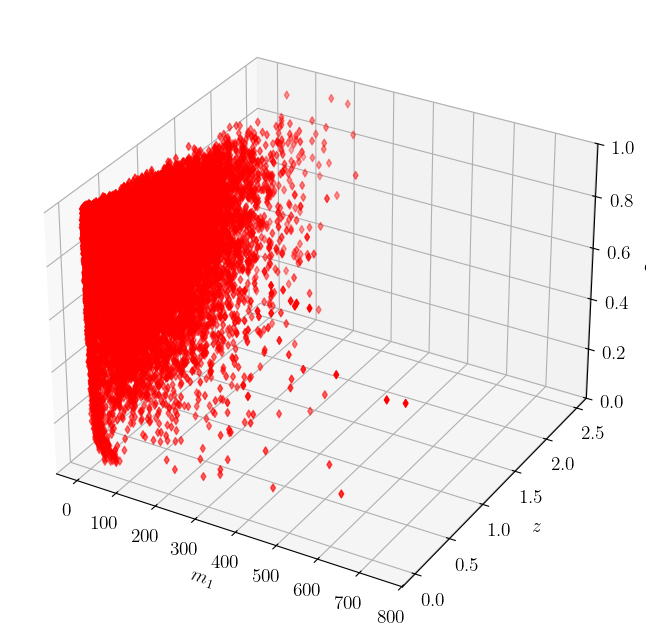

In [63]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.scatter(reduced_injections[:,0], reduced_injections[:,1], reduced_injections[:,2],
           c='r', marker='d', s=4**2, zorder=1,
           # label='Detected injections',
          )
ax.set_xlabel('$m_1$')
#ax.set_xlim(5,200)
ax.set_ylabel('$z$')
ax.set_zlabel('$q$')
ax.set_zlim(0,1)
# ax.legend(loc='upper right', framealpha=0.6)
# ax.set_box_aspect(1)


plt.show()
plt.close()

In [64]:
convex = ConvexHull(reduced_injections)

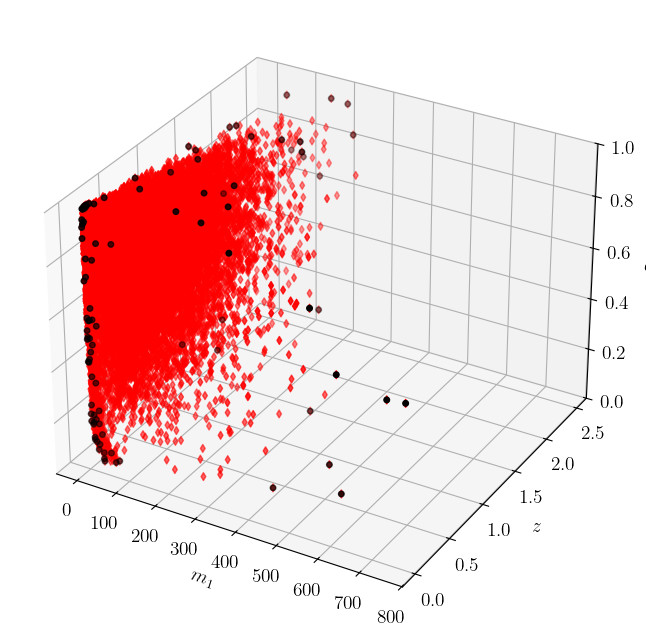

In [65]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.scatter(reduced_injections[:,0], reduced_injections[:,1], reduced_injections[:,2],
           c='r', marker='d', s=4**2, zorder=1,
           # label='Detected injections',
          )

# Show vertices forming the convex hull
vertices = reduced_injections[convex.vertices]
ax.scatter(vertices[:,0], vertices[:,1], vertices[:,2],
           c='k', marker='o', s=4**2, zorder=1,
           # label='Detected injections',
          )


ax.set_xlabel('$m_1$')
#ax.set_xlim(5,200)
ax.set_ylabel('$z$')
ax.set_zlabel('$q$')
ax.set_zlim(0,1)
# ax.legend(loc='upper right', framealpha=0.6)
# ax.set_box_aspect(1)


plt.show()
plt.close()

In [73]:
vertices.shape

(98, 3)

In [67]:
d = Delaunay(vertices)

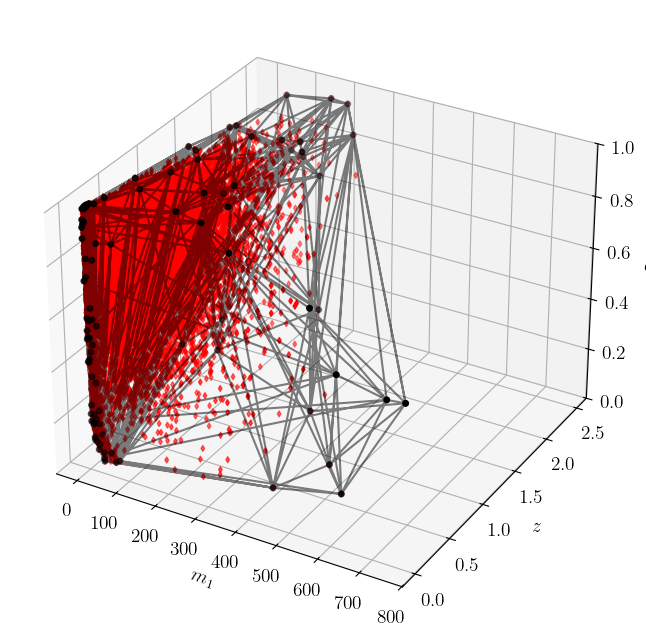

In [72]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.scatter(reduced_injections[:,0], reduced_injections[:,1], reduced_injections[:,2],
           c='r', marker='d', s=3**2, zorder=0,
           # label='Detected injections',
          )

# Show vertices forming the convex hull
vertices = reduced_injections[convex.vertices]
ax.scatter(vertices[:,0], vertices[:,1], vertices[:,2],
           c='k', marker='o', s=4**2, zorder=1,
           # label='Detected injections',
          )

# Show the Delaunay triangulation of these vertices
edges = get_edges(d.simplices)
tri_lines_x = np.insert(vertices[edges,0], 2, np.nan, axis=1)
tri_lines_y = np.insert(vertices[edges,1], 2, np.nan, axis=1)
tri_lines_z = np.insert(vertices[edges,2], 2, np.nan, axis=1)
tri_lines = ax.plot(tri_lines_x.ravel(),
                    tri_lines_y.ravel(),
                    tri_lines_z.ravel(),
                    color="k", ls="-",alpha=0.5,zorder=10,
                    )


ax.set_xlabel('$m_1$')
#ax.set_xlim(5,200)
ax.set_ylabel('$z$')
ax.set_zlabel('$q$')
ax.set_zlim(0,1)
# ax.legend(loc='upper right', framealpha=0.6)
# ax.set_box_aspect(1)


plt.show()
plt.close()

In [74]:
import cv2
import numpy as np

# Get the minimum area rotated rectangle
# Returns: (center (x,y), size (width, height), angle of rotation)
rect = cv2.minAreaRect(reduced_injections)

# Extract the 4 corner points of the rotated box
box_corners = cv2.boxPoints(rect)
box_corners = np.int64(box_corners)

print("Rotated Box Corners:\n", box_corners)

ModuleNotFoundError: No module named 'cv2'

In [39]:
Nevents_prior = np.sum(np.exp(square_rate_prior) *to_comoving_volume[None,:,None,None], axis=(1,2,3)) *dm1 *dz *dq
median_prior = np.quantile(Nevents_prior, 0.5)
low_prior = np.quantile(Nevents_prior, 0.05)
high_prior = np.quantile(Nevents_prior, 0.95)

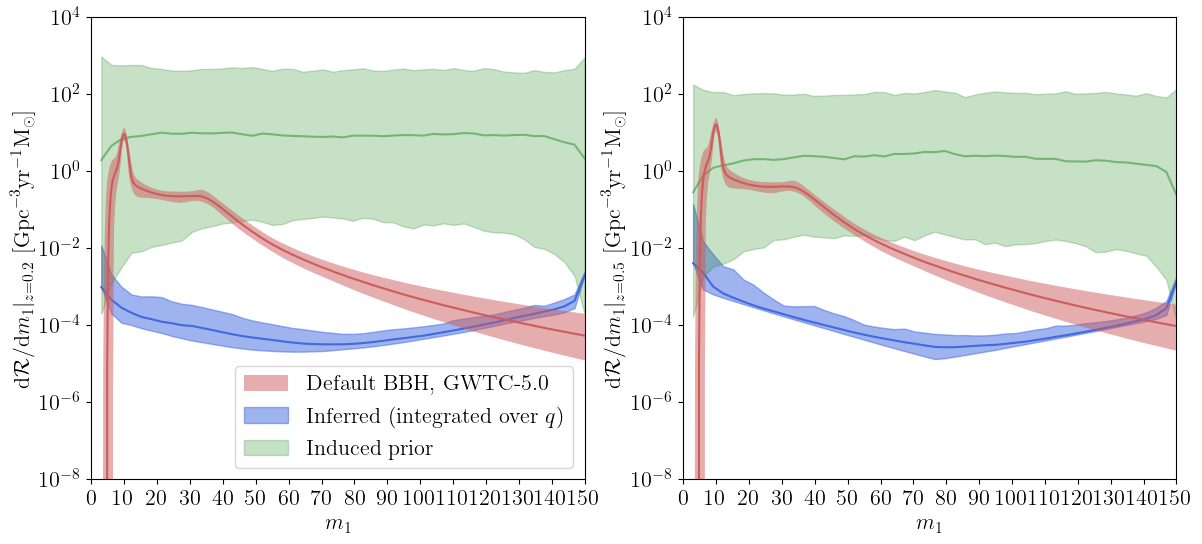

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

z_values_toplot = [0.2,0.5]
ymins = [1e-8, 1e-8]
ymaxs = [1e4, 1e4]

for n,zeval in enumerate(z_values_toplot):
    ax = axes[n]
    redshift_factor_strong_bbh_o4b = (1 + zeval)**(strong_bbh_O4b.get_hyperparameter_samples(hyperparameters=['lamb']))
    zeval_ind = np.argmin(np.abs(z_grid-zeval))

    ax.plot(strong_bbh_O4b_m1_grid, np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.5, axis=0),
            color=spm_color, lw=1.5, zorder=5,
           )
    ax.fill_between(strong_bbh_O4b_m1_grid,
            np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.05, axis=0),
            np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rm1, 0.95, axis=0),
            color=spm_color, edgecolor=None, alpha=0.5, zorder=5,
            label='Default BBH, GWTC-5.0',
            )
    
    dRdm1_zeval = np.sum(np.exp(square_rate[:,zeval_ind,:,:]) *to_comoving_volume[zeval_ind], axis=2) *dq
    low_dRdm1 = np.quantile(dRdm1_zeval, 0.05, axis=0)
    median_dRdm1 = np.quantile(dRdm1_zeval, 0.5, axis=0)
    high_dRdm1 = np.quantile(dRdm1_zeval, 0.95, axis=0)
    
    ax.plot(m1_grid, median_dRdm1, color="royalblue")
    ax.fill_between(m1_grid, low_dRdm1, high_dRdm1,
                    color="royalblue", alpha=0.5,
                    label=r'Inferred (integrated over $q$)',
                    )

    dRdm1_prior_zeval = np.sum(np.exp(square_rate_prior[:,zeval_ind,:,:]) 
                               *to_comoving_volume[zeval_ind], axis=2) *dq
    low_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.05, axis=0)
    median_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.5, axis=0)
    high_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.95, axis=0)
    ax.plot(m1_grid, median_dRdm1_prior, color="forestgreen", alpha=0.5)
    ax.fill_between(m1_grid, low_dRdm1_prior, high_dRdm1_prior,
                    color="forestgreen", alpha=0.25,
                    label='Induced prior',
                    )
    
    ax.set_xlabel(r'$m_1$')
    ax.set_xlim(xmin=m1_min, xmax=m1_max)
    ax.set_xticks(np.linspace(0,m1_max,int(m1_max/10)+1))
    ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}m_1 |_{z=%.1f}\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}\mathrm{M}_\odot]$' %zeval)
    ax.set_yscale('log')
    #ax.set_box_aspect(1)
    ax.set_ylim(ymin=ymins[n], ymax=ymaxs[n])

axes[0].legend(loc='best')
plt.show()
plt.close()

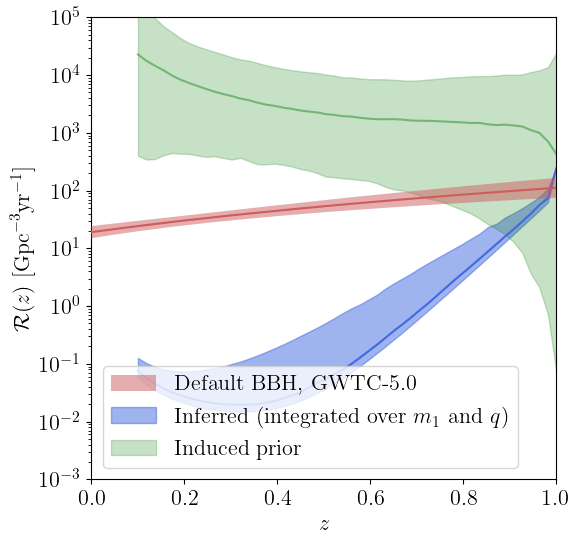

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))

ax.plot(strong_bbh_O4b_z_grid, np.quantile(strong_bbh_O4b_Rz, 0.5, axis=0),
        color=spm_color, lw=1.5, zorder=5,
       )
ax.fill_between(strong_bbh_O4b_z_grid,
        np.quantile(strong_bbh_O4b_Rz, 0.05, axis=0),
        np.quantile(strong_bbh_O4b_Rz, 0.95, axis=0),
        color=spm_color, edgecolor=None, alpha=0.5, zorder=5,
        label='Default BBH, GWTC-5.0'
        )

Rz = np.sum(np.exp(square_rate) 
              *to_comoving_volume[None,:,None,None], axis=(2,3)) *dq *dm1
low_Rz = np.quantile(Rz, 0.05, axis=0)
median_Rz = np.quantile(Rz, 0.5, axis=0)
high_Rz = np.quantile(Rz, 0.95, axis=0)

ax.plot(z_grid, median_Rz, color="royalblue")
ax.fill_between(z_grid, low_Rz, high_Rz,
                color="royalblue", alpha=0.5,
                label=r'Inferred (integrated over $m_1$ and $q$)',
                )

Rz_prior = np.sum(np.exp(square_rate_prior) 
                    *to_comoving_volume[None,:,None,None], axis=(2,3)) *dq *dm1
low_Rz_prior = np.quantile(Rz_prior, 0.05, axis=0)
median_Rz_prior = np.quantile(Rz_prior, 0.5, axis=0)
high_Rz_prior = np.quantile(Rz_prior, 0.95, axis=0)
ax.plot(z_grid, median_Rz_prior, color="forestgreen", alpha=0.5)
ax.fill_between(z_grid, low_Rz_prior, high_Rz_prior,
                color="forestgreen", alpha=0.25,
                label='Induced prior',
                )


ax.set_xlabel(r'$z$')
ax.set_xlim(xmin=z_min, xmax=z_max)
ax.set_xticks(np.linspace(0,z_max,int(z_max*10)+1)[::2])
ax.set_ylabel(r'$\mathcal{R}(z)\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.legend(loc='best')
#ax.set_box_aspect(1)
ax.set_ylim(ymin=1e-3, ymax=1e5)

plt.show()
plt.close()

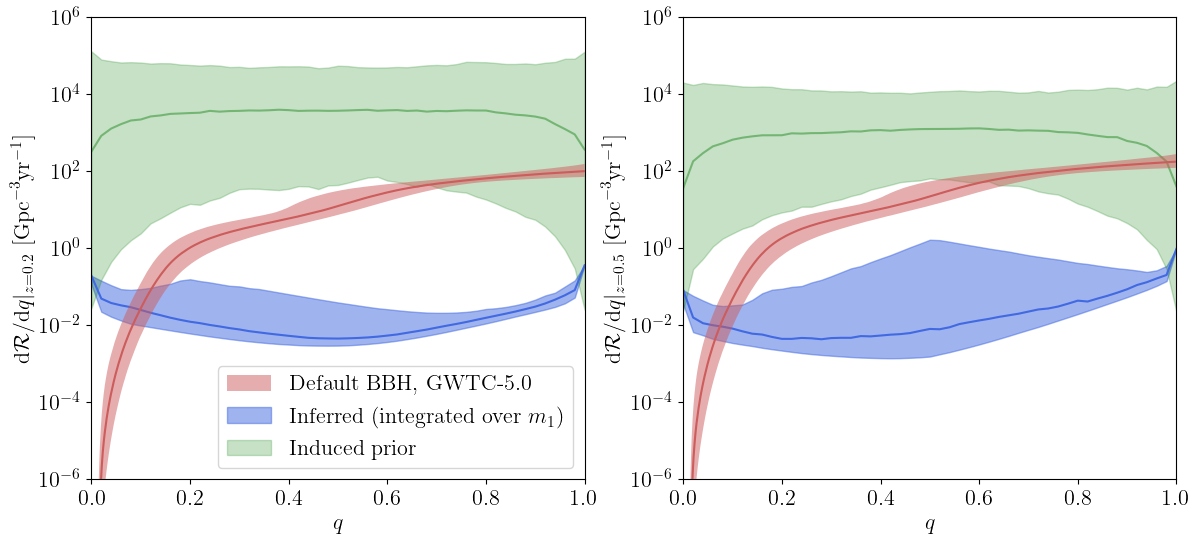

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

z_values_toplot = [0.2,0.5]
ymins = [1e-6, 1e-6]
ymaxs = [1e6, 1e6]

for n,zeval in enumerate(z_values_toplot):
    ax = axes[n]
    redshift_factor_strong_bbh_o4b = (1 + zeval)**(strong_bbh_O4b.get_hyperparameter_samples(hyperparameters=['lamb']))
    zeval_ind = np.argmin(np.abs(z_grid-zeval))

    ax.plot(strong_bbh_O4b_q_grid, np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.5, axis=0),
            color=spm_color, lw=1.5, zorder=5,
           )
    ax.fill_between(strong_bbh_O4b_q_grid,
            np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.05, axis=0),
            np.quantile(redshift_factor_strong_bbh_o4b * strong_bbh_O4b_Rq, 0.95, axis=0),
            color=spm_color, edgecolor=None, alpha=0.5, zorder=5,
            label='Default BBH, GWTC-5.0',
            )
    
    dRdq_zeval = np.sum(np.exp(square_rate[:,zeval_ind,:,:]) 
                        *to_comoving_volume[zeval_ind], axis=1) *dm1
    low_dRdq = np.quantile(dRdq_zeval, 0.05, axis=0)
    median_dRdq = np.quantile(dRdq_zeval, 0.5, axis=0)
    high_dRdq = np.quantile(dRdq_zeval, 0.95, axis=0)
    
    ax.plot(q_grid, median_dRdq, color="royalblue")
    ax.fill_between(q_grid, low_dRdq, high_dRdq,
                    color="royalblue", alpha=0.5,
                    label=r'Inferred (integrated over $m_1$)',
                    )
    
    dRdq_prior_zeval = np.sum(np.exp(square_rate_prior[:,zeval_ind,:,:]) 
                               *to_comoving_volume[zeval_ind], axis=1) *dm1
    low_dRdq_prior = np.quantile(dRdq_prior_zeval, 0.05, axis=0)
    median_dRdq_prior = np.quantile(dRdq_prior_zeval, 0.5, axis=0)
    high_dRdq_prior = np.quantile(dRdq_prior_zeval, 0.95, axis=0)
    ax.plot(q_grid, median_dRdq_prior, color="forestgreen", alpha=0.5)
    ax.fill_between(q_grid, low_dRdq_prior, high_dRdq_prior,
                    color="forestgreen", alpha=0.25,
                    label='Induced prior',
                    )
    
    ax.set_xlabel(r'$q$')
    ax.set_xlim(xmin=q_min, xmax=q_max)
    ax.set_xticks(np.linspace(0,1,6))
    ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}q |_{z=%.1f}\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}]$' %zeval)
    ax.set_yscale('log')
    #ax.set_box_aspect(1)
    ax.set_ylim(ymin=ymins[n], ymax=ymaxs[n])

axes[0].legend(loc='best')
plt.show()
plt.close()

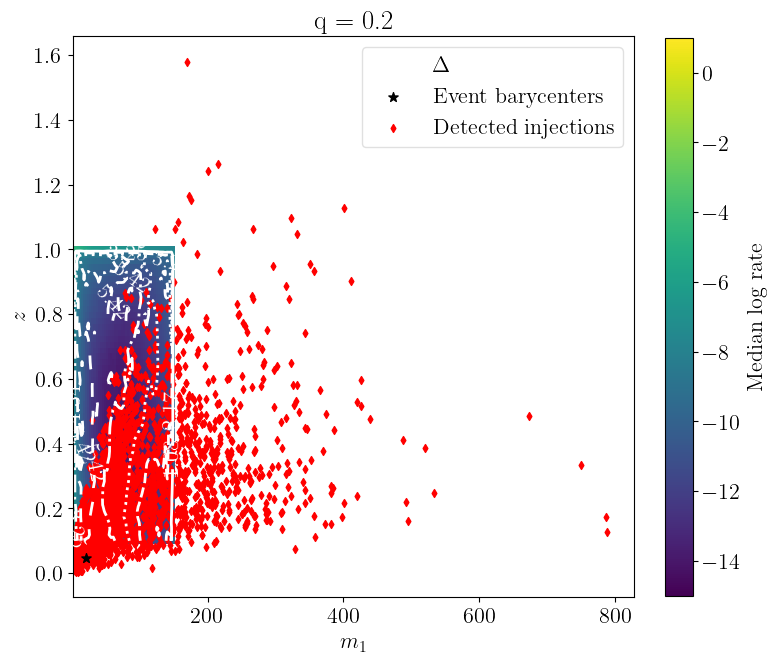

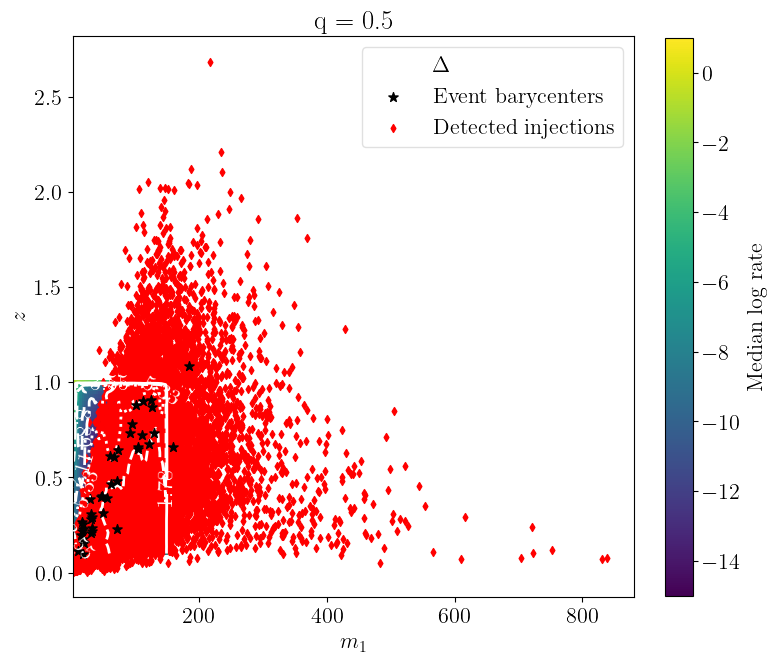

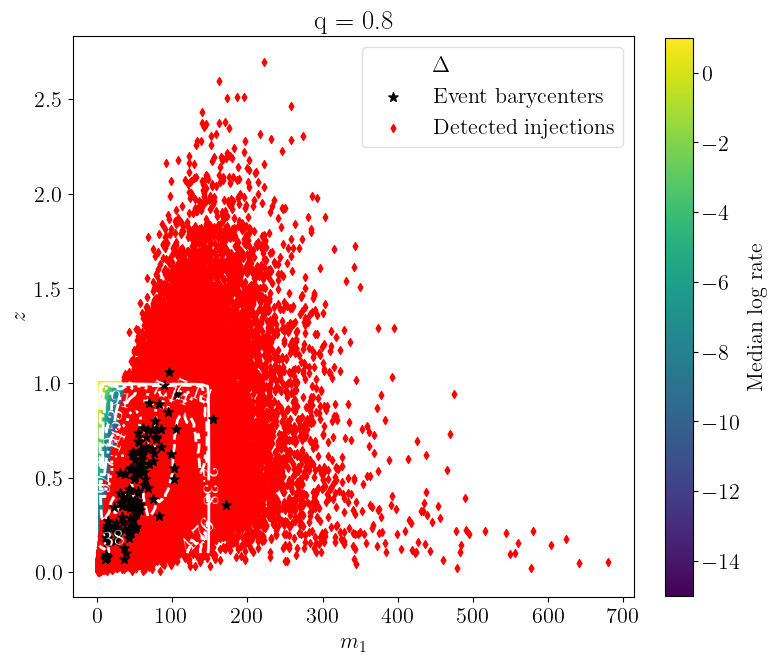

In [43]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

for qeval in [0.2, 0.5, 0.8]:
    qeval_ind = np.argmin(np.abs(q_grid-qeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")


    c = ax.pcolormesh(m1_grid, z_grid, median[:, :, qeval_ind] +np.log(to_comoving_volume[:,None]),
                      cmap=cmap, norm=norm,
                     )
    
    # Calculate the difference
    diff = high[:, :, qeval_ind] - low[:, :, qeval_ind]

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, z_grid, diff, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_q = np.abs(event_barycenters[:,2]-q_grid[qeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_q,0], event_barycenters[events_at_q,1],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    injections_at_q = np.abs(detected_injections[:,2]-q_grid[qeval_ind]) < 0.01
    ax.scatter(detected_injections[injections_at_q,0], detected_injections[injections_at_q,1],
               c='r', marker='d', s=4**2, zorder=1,
               label='Detected injections',
              )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$z$')
    ax.legend(loc='upper right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

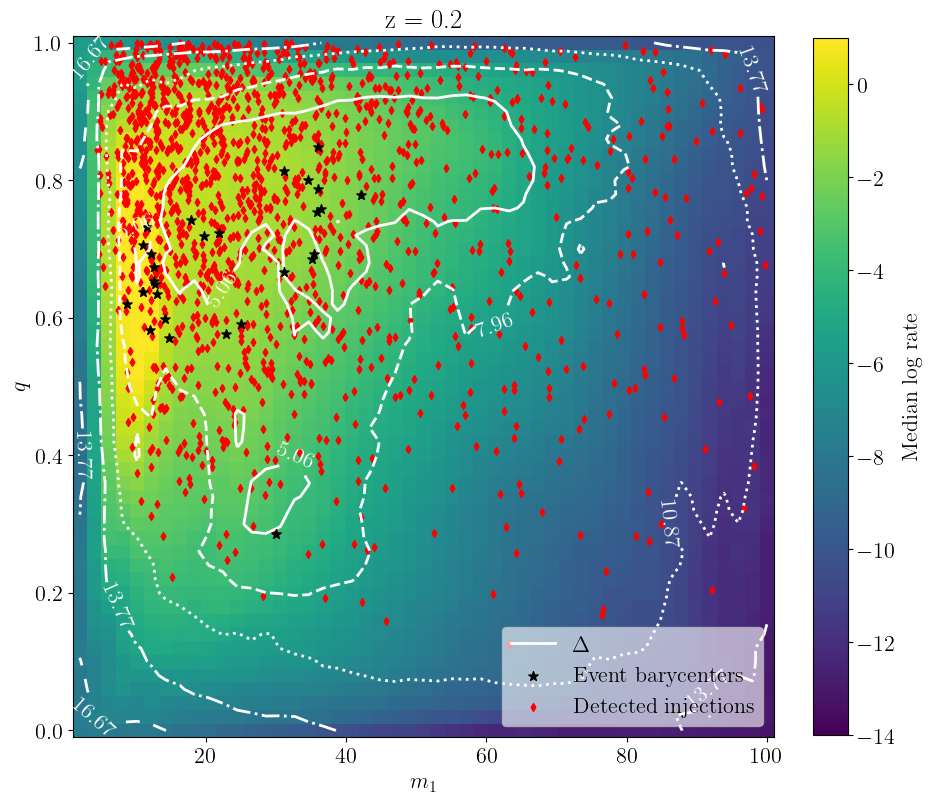

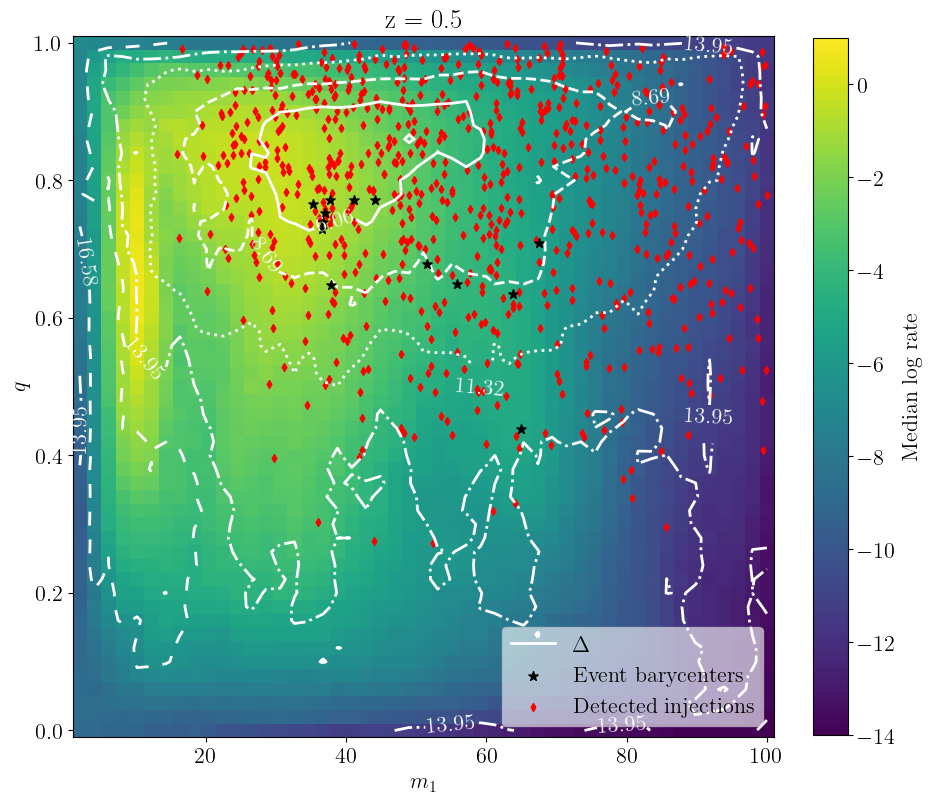

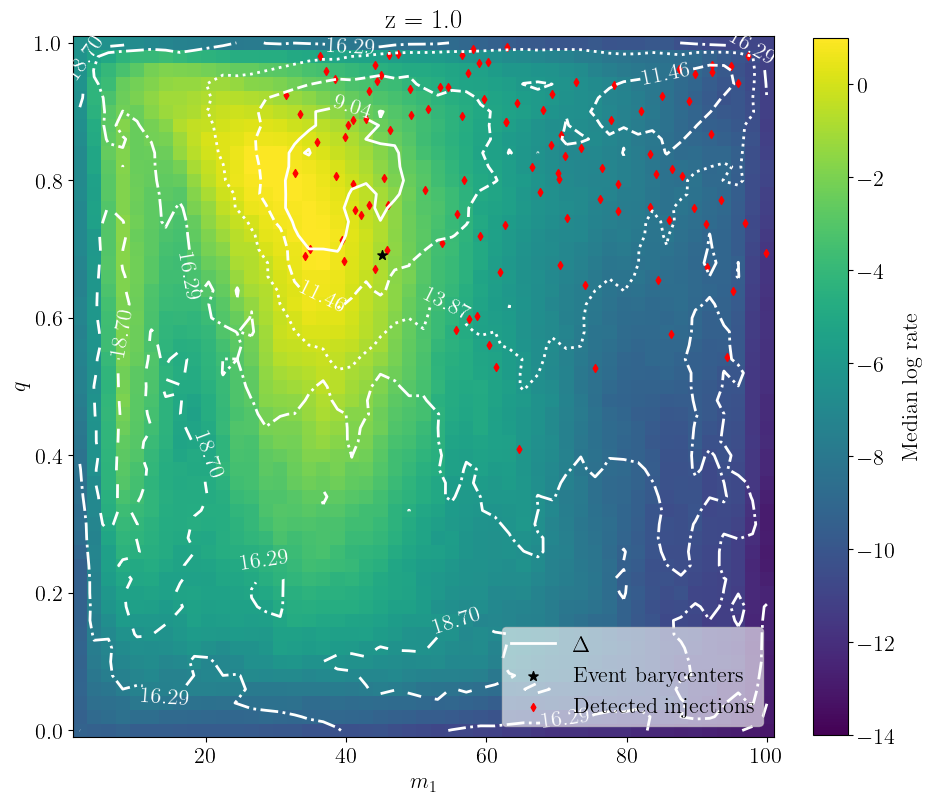

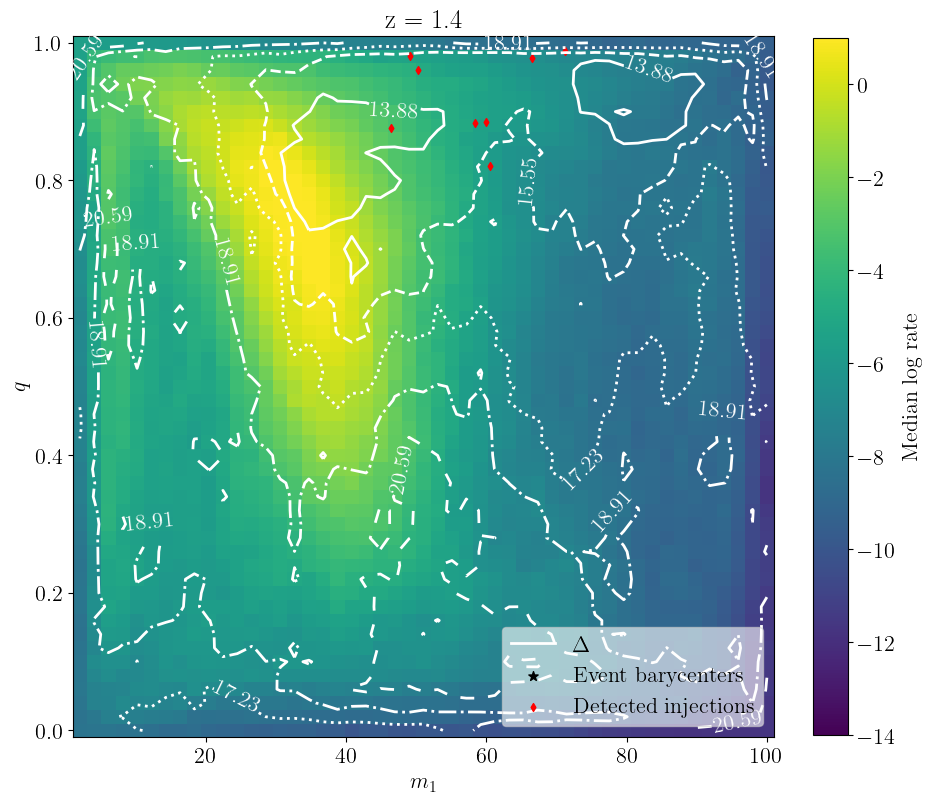

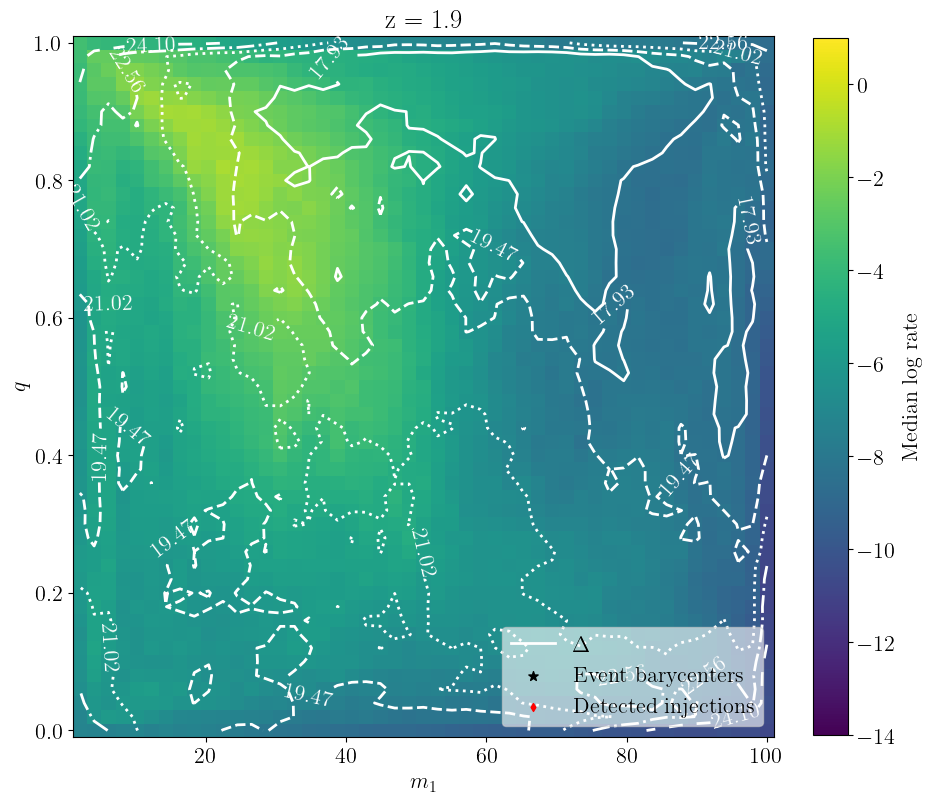

In [112]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

for zeval in [0.2, 0.5, 1.0]:
    zeval_ind = np.argmin(np.abs(z_grid-zeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"z = {z_grid[zeval_ind]:.1f}")   
    
    c = ax.pcolormesh(m1_grid, q_grid, median[zeval_ind, :, :].T +np.log(to_comoving_volume[zeval_ind]),
                      cmap=cmap, norm=norm,
                     )

    
    # Calculate the difference
    diff = high[zeval_ind, :, :] - low[zeval_ind, :, :]

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, q_grid, diff.T, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_z = np.abs(event_barycenters[:,1]-z_grid[zeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_z,0], event_barycenters[events_at_z,2],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    injections_at_z = np.abs(detected_injections[:,1]-z_grid[zeval_ind]) < 0.01
    ax.scatter(detected_injections[injections_at_z,0], detected_injections[injections_at_z,2],
               c='r', marker='d', s=4**2, zorder=1,
               label='Detected injections',
              )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$q$')
    ax.legend(loc='lower right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

### LVK results in 2D

In [26]:
# Downselect to a reasonable number of hyperparameter samples
num_pop_LVK = 50
inds = np.random.choice(np.arange(strong_bbh_O4b_Rz.shape[0]), size=num_pop_LVK, replace=False)

In [45]:
rate_pop_LVK = np.zeros((num_pop_LVK, len(strong_bbh_O4b_z_grid), len(strong_bbh_O4b_m1_grid)))
for ind,pop_ind in enumerate(tqdm(inds)):
    int_dRdm1 = np.trapezoid(x=strong_bbh_O4b_m1_grid, y=strong_bbh_O4b_Rm1[pop_ind])
    rate_pop_LVK[ind] = np.outer(strong_bbh_O4b_Rz[pop_ind], strong_bbh_O4b_Rm1[pop_ind] /int_dRdm1)
median_LVK = np.quantile(rate_pop_LVK, 0.5, axis=0)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 12.63it/s]


/tmp/ipykernel_55087/171705202.py:5: RuntimeWarning: divide by zero encountered in log
  c = ax.pcolormesh(strong_bbh_O4b_m1_grid, strong_bbh_O4b_z_grid, np.log(median_LVK),


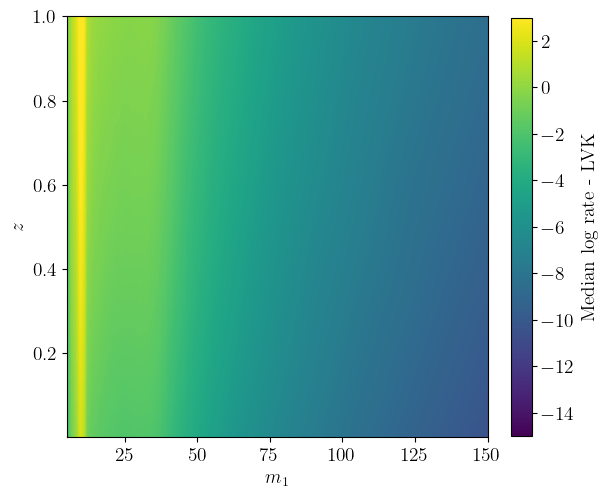

In [48]:
cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=3)

fig, ax = plt.subplots(figsize=(6,6))
c = ax.pcolormesh(strong_bbh_O4b_m1_grid, strong_bbh_O4b_z_grid, np.log(median_LVK),
                  cmap=cmap, norm=norm,
                 )
cbar = fig.colorbar(c, ax=ax, fraction=0.045)
cbar.set_label(r'Median log rate - LVK')


ax.set_xlabel('$m_1$')
ax.set_xlim(m1_min, m1_max)
ax.set_ylabel('$z$')
ax.set_ylim(z_min, z_max)
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

plt.show()
plt.close()

In [13]:
diff = high-low
interp_delta = RegularGridInterpolator((z_grid, m1_grid, q_grid), diff, bounds_error=False, fill_value=np.nan)

NameError: name 'high' is not defined

In [ ]:
qeval = 0.8
qeval_ind = np.argmin(np.abs(q_grid-qeval))

cmap=plt.get_cmap('magma')
norm=mpl.colors.Normalize(vmin=np.min(diff), vmax=np.max(diff))
fig,ax=plt.subplots(figsize=(6,6))
ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")

samples_try=np.zeros((5000,3))

samples_try[:,0]=np.random.uniform(m1_min,m1_max,5000)
samples_try[:,1]=np.random.uniform(z_min,z_max,5000)
samples_try[:,2]=qeval

sc=ax.scatter(samples_try[:,0],samples_try[:,1],
              c=interp_delta(samples_try[:,(1,0,2)]),
              cmap=cmap, norm=norm,
             )
    
ax.set_xlabel(r'$m_1$')
ax.set_ylabel(r'$z$')
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(sc, ax=ax, fraction=0.045)
cbar.set_label(r'$\Delta$')

plt.show()
plt.close()

In [ ]:
delta_levels = np.linspace(np.min(diff), np.max(diff), 20)[1:-1]
print(delta_levels)

In [ ]:
samples_per_tri = 1_000
ndraw = 10_000

ints_delta={}
ints_delta_LVK={}
volume = np.prod(corners.max(axis=0) - corners.min(axis=0))
to_cosmo = interp1d(z_grid, to_comoving_volume, fill_value='extrapolate')
for delta in delta_levels:
    print(delta)
    nprop=0
    nkeep=0
    nkeep_old=0

    proposals=np.zeros((ndraw,3))
    cosmo_fac=np.zeros(ndraw)

    while nkeep<ndraw:
        
        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(m1_min,m1_max,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(z_min,z_max,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(q_min,q_max,ndraw-nkeep)

        nprop+=ndraw-nkeep       
        inds_proposal_keep=np.argwhere(interp_delta(new_points[:,(1,0,2)])<delta)[:,0]
        nkeep+=len(inds_proposal_keep)
        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]
        cosmo_fac=to_cosmo(proposals[:,1])
        nkeep_old+=len(inds_proposal_keep)

    frac_kept = nkeep / nprop

    ints_delta[delta]=np.zeros(num_triangulations)
    ints_delta_LVK[delta]=np.zeros(num_pop_LVK)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        #mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        mean_fx = np.mean(np.exp(this_delo.interpolate(proposals)) *cosmo_fac)
        ints_delta[delta][ind] = mean_fx * frac_kept * volume

    for n,pop_ind in enumerate(tqdm(inds)):
        int_dRdm1 = np.trapezoid(x=strong_bbh_O4b_m1_grid, y=strong_bbh_O4b_Rm1[pop_ind])
        int_dRdq = np.trapezoid(x=strong_bbh_O4b_q_grid, y=strong_bbh_O4b_Rq[pop_ind])
        pdf_m1 = interp1d(x=strong_bbh_O4b_m1_grid, 
                          y=strong_bbh_O4b_Rm1[pop_ind] /int_dRdm1, 
                          fill_value="extrapolate",
                         )
        rate_z = interp1d(x=strong_bbh_O4b_z_grid, 
                          y=strong_bbh_O4b_Rz[0], 
                          fill_value="extrapolate",
                         )
        pdf_q = interp1d(x=strong_bbh_O4b_q_grid, 
                         y=strong_bbh_O4b_Rq[pop_ind] /int_dRdq, 
                         fill_value="extrapolate",
                        )
        mean_Nx = (
            pdf_m1(proposals[:,0])
            *rate_z(proposals[:,1])
            *pdf_q(proposals[:,2])
        ).mean()       
        ints_delta_LVK[delta][ind] = mean_Nx * frac_kept * volume

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

median_LVK = [ np.median(ints_delta_LVK[delta]) for delta in delta_levels]
low_LVK = [ np.quantile(ints_delta_LVK[delta], 0.05) for delta in delta_levels]
high_LVK = [ np.quantile(ints_delta_LVK[delta], 0.95) for delta in delta_levels]
ax.plot(delta_levels, median_LVK, "--", color="black", zorder=3, label="LVK population results")
ax.fill_between(delta_levels, low_LVK, high_LVK, 
                alpha=0.4, color="black")

median_delta = [ np.median(ints_delta[delta]) for delta in delta_levels]
low_delta = [ np.quantile(ints_delta[delta], 0.05) for delta in delta_levels]
high_delta = [ np.quantile(ints_delta[delta], 0.95) for delta in delta_levels]
ax.plot(delta_levels, median_delta, label='Inferred')
ax.fill_between(delta_levels, low_delta, high_delta, alpha=0.4)

ax.errorbar(delta_levels[-1]*1.05, median_prior, np.array([[median_prior-low_prior,high_prior-median_prior]]).T,
            color='firebrick', alpha=0.6, linewidth=2, capsize=6, fmt='.',
            label="Prior",
           )

# np.savez("3D_volume_delta.np", kl=kl_levels, median=median, low=low, high=high)
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$\int\int\int\ \mathcal{R}(m_1,z,q)\mathrm{d}m_1\mathrm{d}z\mathrm{d}q$')
ax.set_yscale('log')
#ax.set_ylim(ymin=1e1, ymax=1e5)

ax.legend(loc='lower right')
ax.set_box_aspect(1)
# plt.savefig("3D_volume_delta")
plt.show()
plt.close()

In [ ]:
m1_grid_coarse = np.linspace(m1_min, m1_max, 19)
z_grid_coarse = np.linspace(0.1, z_max, 20)
q_grid_coarse = np.linspace(q_min, q_max, 21)

X_coarse, Y_coarse, Z_coarse = np.meshgrid(m1_grid_coarse, z_grid_coarse, q_grid_coarse)
grid_coarse = np.c_[X_coarse.ravel(), Y_coarse.ravel(), Z_coarse.ravel()]

dm1_coarse = m1_grid_coarse[1] - m1_grid_coarse[0]
dz_coarse = z_grid_coarse[1] - z_grid_coarse[0]
dq_coarse = q_grid_coarse[1] - q_grid_coarse[0]

to_comoving_volume_coarse = (1 + z_grid_coarse) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z_grid_coarse).to(u.Gpc**3 / u.sr).value
    )

In [ ]:
log_rate_coarse = np.zeros((num_triangulations, grid_coarse.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate_coarse[ind] = this_delo.interpolate(grid_coarse)
    
square_rate_coarse = log_rate_coarse.reshape(num_triangulations, z_grid_coarse.shape[0], m1_grid_coarse.shape[0], q_grid_coarse.shape[0])

In [ ]:
nsamples_prior = 1_000
log_rate_prior_coarse = np.zeros((nsamples_prior, grid_coarse.shape[0]))

for i in tqdm(range(nsamples_prior)):
    nleaves_i = np.random.randint(nvertices_min, nvertices_max)
    tri_i = np.zeros((nleaves_i+offset,ndim+1))
    tri_i[:offset,:-1] = corners
    tri_i[offset:,0] = np.random.uniform(m1_min, m1_max, nleaves_i)
    tri_i[offset:,1] = np.random.uniform(z_min, z_max, nleaves_i)
    tri_i[offset:,2] = np.random.uniform(q_min, q_max, nleaves_i)
    tri_i[:,-1] = np.random.uniform(w_min, w_max, nleaves_i+offset)
   
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri_i)
    log_rate_prior_coarse[i] = this_delo.interpolate(grid_coarse)

square_rate_prior_coarse = log_rate_prior_coarse.reshape(nsamples_prior, z_grid_coarse.shape[0], m1_grid_coarse.shape[0], q_grid_coarse.shape[0])

In [ ]:
kl_divs=np.zeros((len(z_grid_coarse),len(m1_grid_coarse),len(q_grid_coarse)))

for i,j,k in product(range(z_grid_coarse.shape[0]),range(m1_grid_coarse.shape[0]),range(q_grid_coarse.shape[0])):
    kl_divs[i,j,k] = kl_divergence_kde(square_rate_coarse[:,i,j,k],square_rate_prior_coarse[:,i,j,k])

In [ ]:
interp_kl = RegularGridInterpolator((z_grid_coarse, m1_grid_coarse, q_grid_coarse), kl_divs, bounds_error=False, fill_value=np.nan)

In [ ]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

for qeval in [0.2, 0.5, 0.8]:
    qeval_ind = np.argmin(np.abs(q_grid-qeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")

    c = ax.pcolormesh(m1_grid, z_grid, median[:, :, qeval_ind] +np.log(to_comoving_volume[:,None]),
                      cmap=cmap, norm=norm,
                     )

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels_kl = np.linspace(np.nanmin(kl_divs), np.nanmax(kl_divs), n_contours + 2)[1:-1]  # avoid min/max

    Xz0, Yz0, Zz0 = np.meshgrid(m1_grid, z_grid, np.array([q_grid[qeval_ind]]))
    # grid_z0 = np.c_[Xz0.ravel(), Yz0.ravel(), Zz0.ravel()]
    grid_z0 = np.c_[Yz0.ravel(), Xz0.ravel(), Zz0.ravel()]

    # Plot contours with different linestyles
    contours_kl = ax.contour(
        m1_grid, z_grid, interp_kl(grid_z0).reshape(len(z_grid),len(m1_grid)), 
        levels=levels_kl, 
        linestyles=linestyles[:n_contours][::-1],
        linewidths=2, 
        colors='black'
    )
    ax.clabel(contours_kl, fmt="%.2f")
    ax.plot([],[], lw=2, color='k', label='KL')

    ## Overplot contours of diff log-rate ## 35
    # Calculate the difference
    diff = high[:, :, qeval_ind] - low[:, :, qeval_ind]
    # Define contour levels (choose appropriate values for your data)
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max
    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, z_grid, diff, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_q = np.abs(event_barycenters[:,2]-q_grid[qeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_q,0], event_barycenters[events_at_q,1],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    # injections_at_q = np.abs(detected_injections[:,2]-q_grid[qeval_ind]) < 0.01
    # ax.scatter(detected_injections[injections_at_q,0], detected_injections[injections_at_q,1],
    #            c='r', marker='d', s=4**2, zorder=1,
    #            label='Detected injections',
    #           )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$z$')
    ax.legend(loc='upper right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

In [ ]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

cmap=plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

for zeval in [0.2, 0.5, 1.0]:
    zeval_ind = np.argmin(np.abs(z_grid-zeval))
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set(title=f"z = {z_grid[zeval_ind]:.1f}")   
    
    c = ax.pcolormesh(m1_grid, q_grid, median[zeval_ind, :, :].T +np.log(to_comoving_volume[zeval_ind]),
                      cmap=cmap, norm=norm,
                     )

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels_kl = np.linspace(np.nanmin(kl_divs), np.nanmax(kl_divs), n_contours + 2)[1:-1]  # avoid min/max

    Xz0, Yz0, Zz0 = np.meshgrid(m1_grid, np.array([z_grid[zeval_ind]]), q_grid)
    # grid_z0 = np.c_[Xz0.ravel(), Yz0.ravel(), Zz0.ravel()]
    grid_z0 = np.c_[Yz0.ravel(), Xz0.ravel(), Zz0.ravel()]

    # Plot contours with different linestyles
    contours_kl = ax.contour(
        m1_grid, q_grid, interp_kl(grid_z0).reshape(len(m1_grid),len(q_grid)).T, 
        levels=levels_kl, 
        linestyles=linestyles[:n_contours][::-1],
        linewidths=2, 
        colors='black'
    )
    ax.clabel(contours_kl, fmt="%.2f")
    ax.plot([],[], lw=2, color='k', label='KL')

    
    # Calculate the difference
    diff = high[zeval_ind, :, :] - low[zeval_ind, :, :]

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours = ax.contour(
        m1_grid, q_grid, diff.T, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )
    ax.clabel(contours, fmt="%.2f")
    ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

    events_at_z = np.abs(event_barycenters[:,1]-z_grid[zeval_ind]) < 0.1
    ax.scatter(event_barycenters[events_at_z,0], event_barycenters[events_at_z,2],
               c='k', marker='*', s=7**2, zorder=2,
               label='Event barycenters',
              )

    # injections_at_z = np.abs(detected_injections[:,1]-z_grid[zeval_ind]) < 0.01
    # ax.scatter(detected_injections[injections_at_z,0], detected_injections[injections_at_z,2],
    #            c='r', marker='d', s=4**2, zorder=1,
    #            label='Detected injections',
    #           )
    ax.set_xlabel('$m_1$')
    ax.set_ylabel('$q$')
    ax.legend(loc='lower right', framealpha=0.6)
    ax.set_box_aspect(1)

    cbar = fig.colorbar(c, ax=ax, fraction=0.045)
    cbar.set_label(r'Median log rate')
    
    plt.show()
    plt.close()

In [ ]:
qeval = 0.8
qeval_ind = np.argmin(np.abs(q_grid-qeval))

cmap=plt.get_cmap('magma')
norm=mpl.colors.Normalize(vmin=np.min(kl_divs), vmax=np.max(kl_divs))
fig,ax=plt.subplots(figsize=(6,6))
ax.set(title=f"q = {q_grid[qeval_ind]:.1f}")

samples_try=np.zeros((5000,3))

samples_try[:,0]=np.random.uniform(m1_min,m1_max,5000)
samples_try[:,1]=np.random.uniform(z_min,z_max,5000)
samples_try[:,2]=qeval

sc=ax.scatter(samples_try[:,0],samples_try[:,1],
              c=interp_kl(samples_try[:,(1,0,2)]),
              cmap=cmap, norm=norm,
             )
    
ax.set_xlabel(r'$m_1$')
ax.set_ylabel(r'$z$')
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(sc, ax=ax, fraction=0.045)
cbar.set_label(r'KL divergence')

plt.show()
plt.close()

In [ ]:
kl_levels = np.linspace(0, np.max(kl_divs), 20)[1:-1]
print(kl_levels)

In [ ]:
samples_per_tri = 1_000
ndraw = 10_000

ints_kl={}
ints_kl_LVK={}
volume = np.prod(corners.max(axis=0) - corners.min(axis=0))
to_cosmo = interp1d(z_grid, to_comoving_volume, fill_value='extrapolate')
for kl in np.flip(kl_levels):
    print(kl)
    nprop=0
    nkeep=0
    nkeep_old=0

    proposals=np.zeros((ndraw,3))
    cosmo_fac=np.zeros(ndraw)
    while nkeep<ndraw:
        
        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(m1_min,m1_max,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(z_min,z_max,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(q_min,q_max,ndraw-nkeep)

        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_kl(new_points[:,(1,0,2)])>kl)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)
        nkeep+=len(inds_proposal_keep)
        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]
        cosmo_fac=to_cosmo(proposals[:,1])

        nkeep_old+=len(inds_proposal_keep)

    frac_kept = nkeep / nprop

    ints_kl[kl]=np.zeros(num_triangulations)
    ints_kl_LVK[kl]=np.zeros(num_pop_LVK)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        #mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        mean_fx = np.mean(np.exp(this_delo.interpolate(proposals)) *cosmo_fac)        
        ints_kl[kl][ind]= mean_fx * frac_kept * volume

    for n,pop_ind in enumerate(tqdm(inds)):
        int_dRdm1 = np.trapezoid(x=strong_bbh_O4b_m1_grid, y=strong_bbh_O4b_Rm1[pop_ind])
        int_dRdq = np.trapezoid(x=strong_bbh_O4b_q_grid, y=strong_bbh_O4b_Rq[pop_ind])
        pdf_m1 = interp1d(x=strong_bbh_O4b_m1_grid, 
                          y=strong_bbh_O4b_Rm1[pop_ind] /int_dRdm1, 
                          fill_value="extrapolate",
                         )
        rate_z = interp1d(x=strong_bbh_O4b_z_grid, 
                          y=strong_bbh_O4b_Rz[0], 
                          fill_value="extrapolate",
                         )
        pdf_q = interp1d(x=strong_bbh_O4b_q_grid, 
                         y=strong_bbh_O4b_Rq[pop_ind] /int_dRdq, 
                         fill_value="extrapolate",
                        )
        mean_Nx = (
            pdf_m1(proposals[:,0])
            *rate_z(proposals[:,1])
            *pdf_q(proposals[:,2])
        ).mean()       
        ints_kl_LVK[kl][ind] = mean_Nx * frac_kept * volume

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

median_LVK = [ np.median(ints_kl_LVK[delta]) for delta in kl_levels]
low_LVK = [ np.quantile(ints_kl_LVK[delta], 0.05) for delta in kl_levels]
high_LVK = [ np.quantile(ints_kl_LVK[delta], 0.95) for delta in kl_levels]

ax.plot(kl_levels, median_LVK, "--", color="black", zorder=3, label="LVK population results")
ax.fill_between(kl_levels, low_LVK, high_LVK, 
                alpha=0.4, color="black")

median_kl = [ np.median(ints_kl[kl]) for kl  in kl_levels]
low_kl = [ np.quantile(ints_kl[kl], 0.05) for kl  in kl_levels]
high_kl = [ np.quantile(ints_kl[kl], 0.95) for kl  in kl_levels]

ax.plot(kl_levels, median_kl, label='Inferred')
ax.fill_between(kl_levels, low_kl, high_kl, alpha=0.4)

ax.errorbar(0, median_prior, np.array([[median_prior-low_prior,high_prior-median_prior]]).T,
            color='firebrick', alpha=0.6, linewidth=2, capsize=6, fmt='.',
            label="Prior",
           )

ax.set_xlabel(r'KL')
ax.set_ylabel(r'$\int\int\int\ \mathcal{R}(m_1,z,q)\mathrm{d}m_1\mathrm{d}z\mathrm{d}q$')
ax.set_yscale('log')
#ax.set_ylim(ymin=1e1, ymax=1e5)

ax.legend(loc='lower left')
ax.set_box_aspect(1)
# plt.savefig("3D_volume_delta")
plt.show()
plt.close()